In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
from scipy.stats import linregress
from scipy.signal import detrend

# font required by PUP:
plt.rcParams['font.family'] = 'Myriad Pro'

# Import the csv dataset:
# -----------------------
data_dir='../../../Data-for-teaching-staff/Forest-fires/'
data_file='Abatzoglou-Williams-2016-west-US/pnas.1607171113.sd01.csv'
dataset = pd.read_csv(data_dir+data_file,na_values='NaN',comment='%',skipinitialspace=True,skip_blank_lines=True,header=0)
data = np.asarray(dataset.iloc[:, :].values)
header = dataset.iloc[:, :].columns

print("Using columns 0,1,9,37 with: ",header[[0,1,9,37]])
years=data[:,0]
area_burnt=data[:,1]/100 # convert from hectars to km^2
VPD=data[:,9]
VPD[np.isnan(area_burnt)]=np.nan
# read VPD with the effects of ACC (Anthropogenic Climate Change) taken out:
VPD_NOACC=data[:,37]

# set up data arrays that correspond only to years 
# in which burnt area data are available:
VPD=1.0*VPD[~np.isnan(area_burnt)]; 
years=1.0*years[~np.isnan(area_burnt)]
VPD_NOACC=1.0*VPD_NOACC[~np.isnan(area_burnt)]
area_burnt=1.0*area_burnt[~np.isnan(area_burnt)]

# calculate the effects of ACC:
VPD_ACC=VPD-VPD_NOACC

print("done.")

Using columns 0,1,9,37 with:  Index(['year', 'area burned', 'Z VPD', 'Z_NOACC VPD'], dtype='object')
done.


In [2]:
# save variables to be picked for students:
np.save("Output/to-pickle/west_US_VPD.npy",VPD)
np.save("Output/to-pickle/west_US_VPD_NOACC.npy",VPD_NOACC)
np.save("Output/to-pickle/west_US_area_burnt.npy",area_burnt)
np.save("Output/to-pickle/west_US_years.npy",years)
print("susscesfully completed.")

susscesfully completed.


VPD/area_burnt fit results WITHOUT DETRENDING: 
   slope=0.422118, intercept=3.14417, p=6.39337e-11, r^2=0.764074.
VPD/area_burnt fit results AFTERE DETRENDING: 
   slope=0.367448, intercept=-1.06691e-15, p=9.7618e-10, r^2=0.717603.
p= 6.39336765243192e-11 specifying p<0.001.


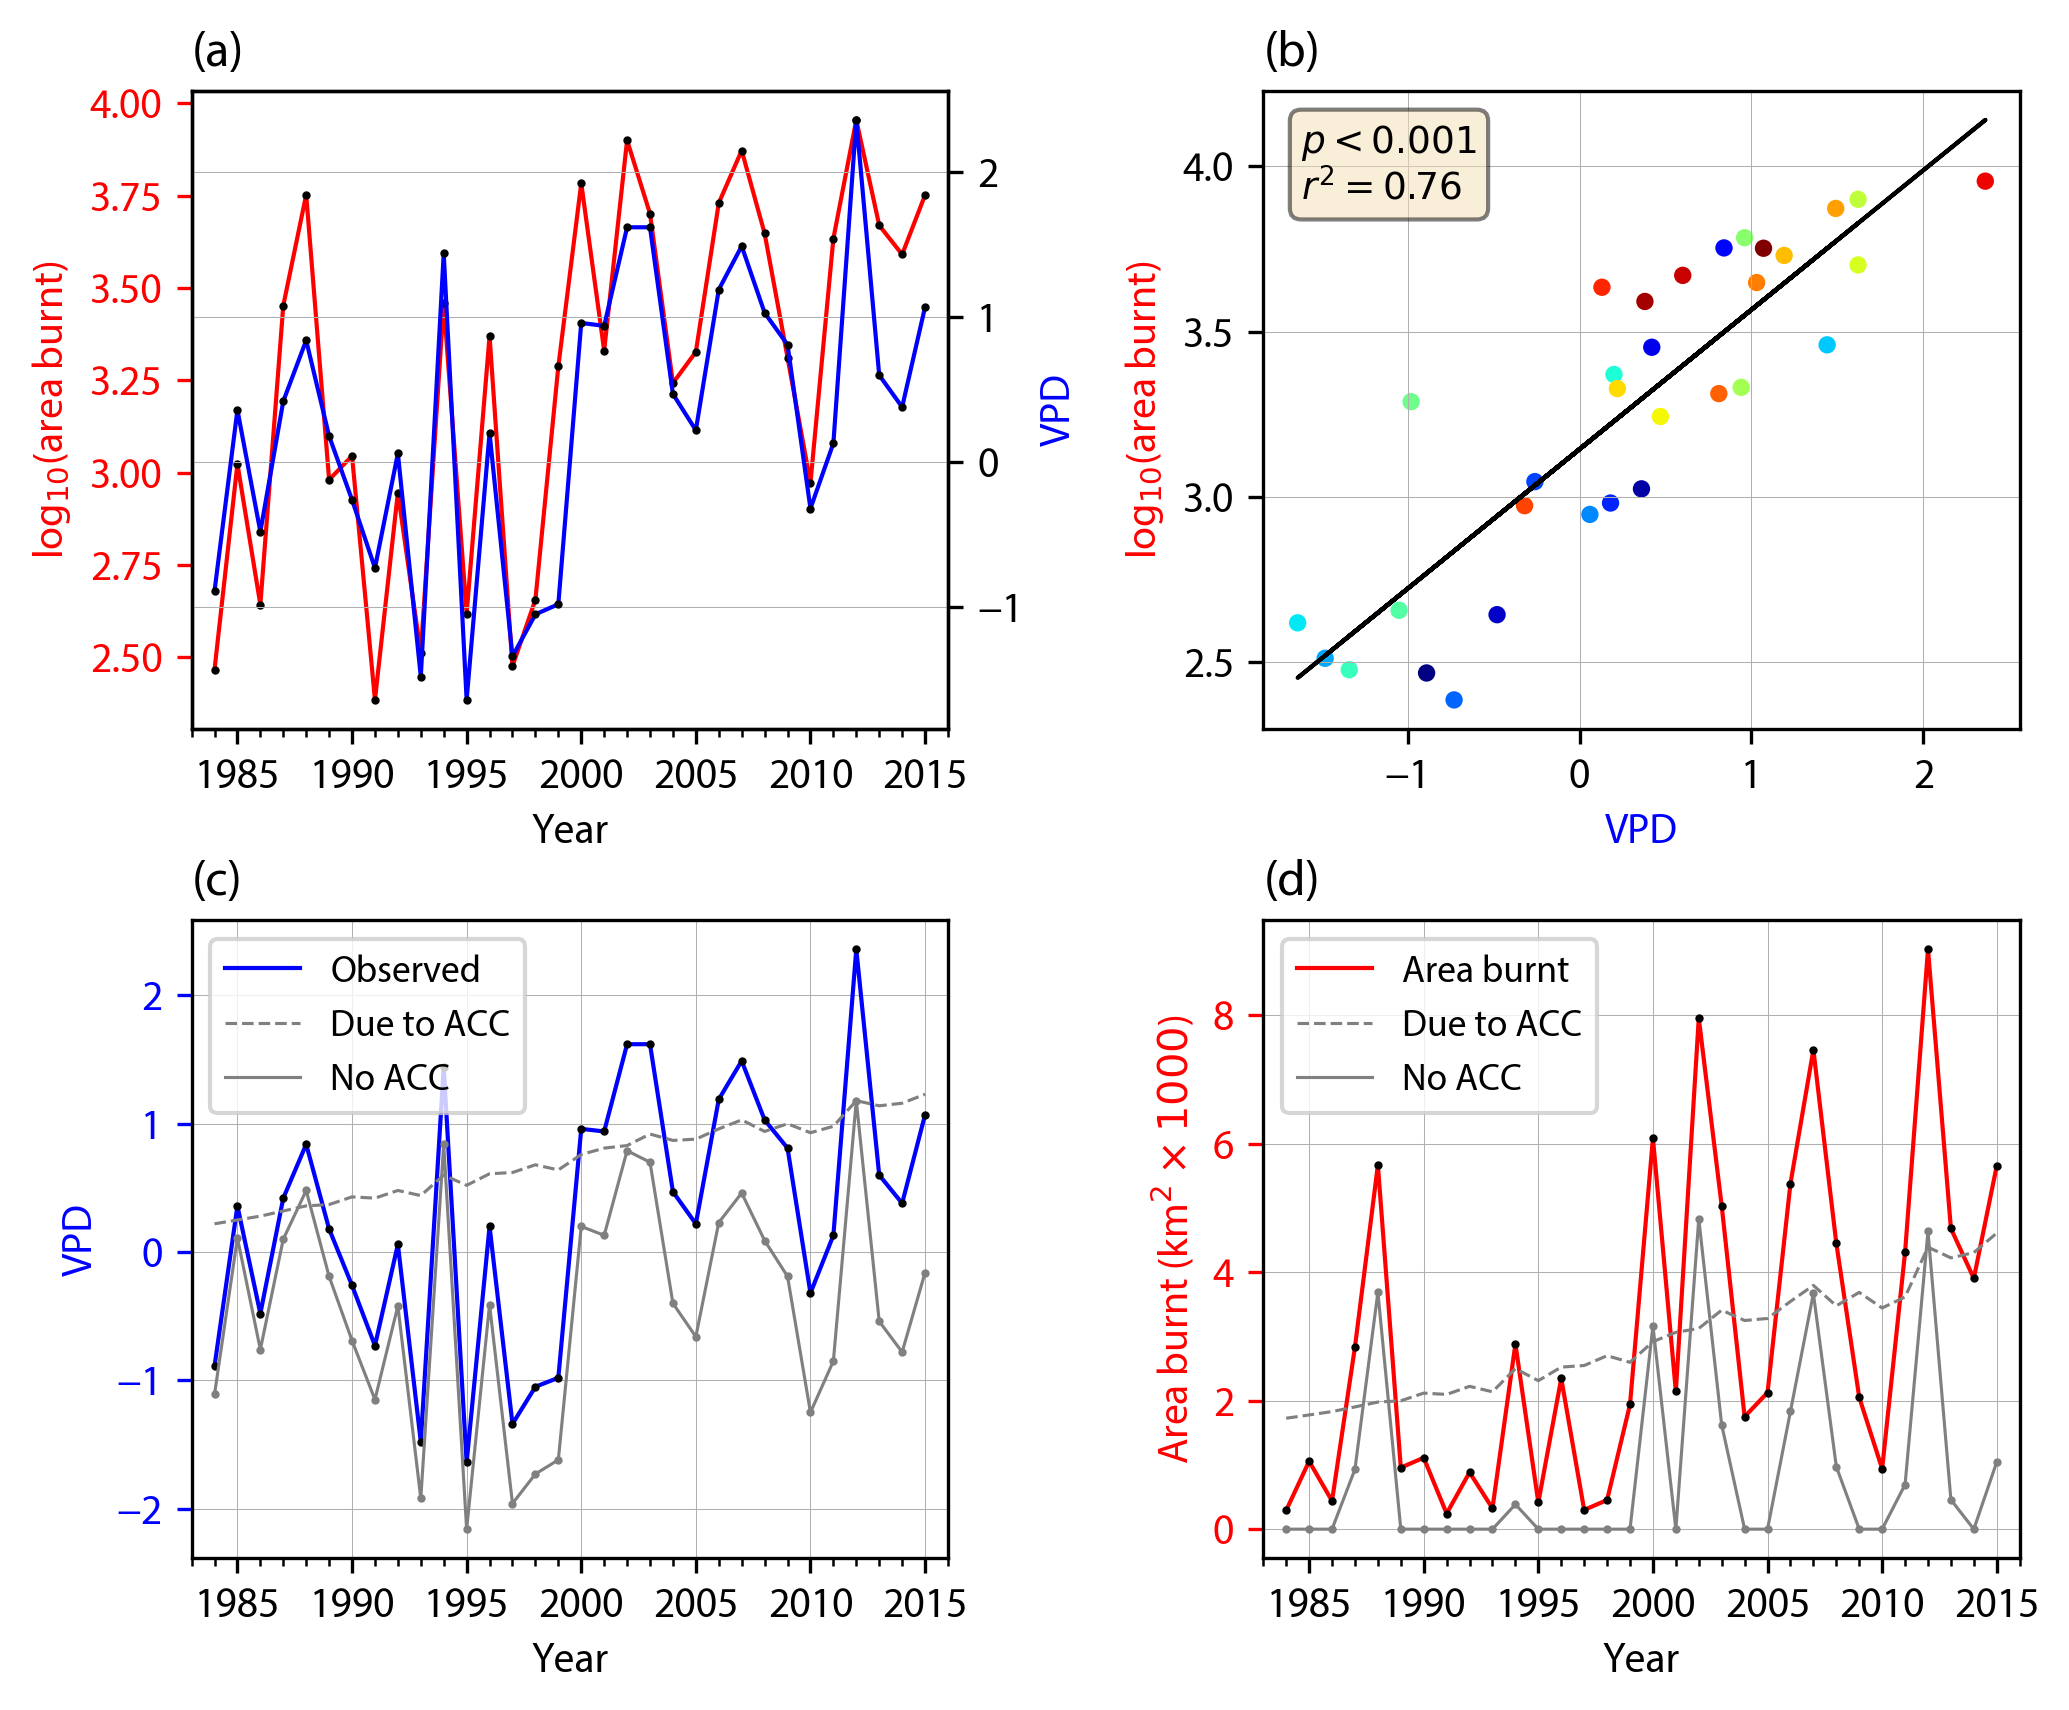

In [3]:

# ------------------------------------------------------------------------
# Fit a regression line to the VPD-burnt area relation WITHOUT DETRENDING:
# ------------------------------------------------------------------------
x=1.0*VPD
y=1.0*np.log10(area_burnt);
fit=linregress(x, y)
slope=fit.slope;
intercept=fit.intercept;
p=fit.pvalue;
r2=(fit.rvalue)**2
print("VPD/area_burnt fit results WITHOUT DETRENDING:"
      ,"\n   slope=%g, intercept=%g, p=%g, r^2=%g." 
     % (slope,intercept,p,r2))


# ----------------------------------------------------------------------
# Fit a regression line to the VPD-burnt area relation AFTER DETRENDING:
# ----------------------------------------------------------------------
log_area=1.0*np.log10(area_burnt[~np.isnan(area_burnt)]);
VPD_detrended=1.0*detrend(VPD, type='linear')
log_area_detrended=1.0*detrend(log_area, type='linear')

fit_detrended=linregress(VPD_detrended, log_area_detrended)
slope_detrended=fit_detrended.slope;
intercept_detrended=fit_detrended.intercept;
p_detrended=fit_detrended.pvalue;
r2_detrended=(fit_detrended.rvalue)**2
print("VPD/area_burnt fit results AFTERE DETRENDING:"
      ,"\n   slope=%g, intercept=%g, p=%g, r^2=%g." 
     % (slope_detrended,intercept_detrended,p_detrended,r2_detrended))


# Calculate the effect of ACC VPD on fires using the calculated regression:
# -------------------------------------------------------------------------
burnt_area_due_to_ACC=10**(intercept+slope*VPD_ACC)
# burnt area without effect of ACC:
area_burnt_NOACC=area_burnt-burnt_area_due_to_ACC
area_burnt_NOACC[area_burnt_NOACC<0]=0


fig=plt.figure(figsize=(7,5.8),dpi=300)
#props1 = dict(boxstyle='round', edgecolor="white", facecolor='white', alpha=1.0)

plt.subplot(2,2,1)
# --------------------------------------
# plot NON-DETRENDED burnt area and VPD:
# --------------------------------------
ax1 = plt.gca()
ax1.plot(years,log_area,lw=1,color="r",label="log area burnt")
ax1.plot(years,log_area,'.',markersize=2,color="k")
ax1.set_xticks(range(1985,2020,5), minor=False)
ax1.set_xticks(range(1983,2017,1), minor=True)
ax2 = ax1.twinx()
ax2.plot(years,VPD,lw=1,color="b",label="VPD")
ax2.plot(years,VPD,'.',markersize=2,color="k")
ax1.set_xlim([1983,2016])
ax1.set_xlabel("Year")
ax1.set_ylabel("log$_{10}$(area burnt)",color="r")
ax2.set_ylabel("VPD",color="b")
ax1.tick_params(axis='y', colors="r")
plt.grid(lw=0.25)
plt.title("(a)",loc="left")
# ax1.text(0.45, 0.97, "(a)", transform=ax1.transAxes, fontsize=12,
#         verticalalignment='top', bbox=props1)


# ----------------------------------
# plot VPD to burnt area regression:
# ----------------------------------
plt.subplot(2,2,2)
plt.scatter(VPD,log_area,c=years,s=10,cmap='jet')
# plot the fitted regression line:
plt.plot(VPD,VPD*slope+intercept,color="k",lw=1)
plt.xlabel("VPD",color="b")
plt.ylabel("log$_{10}$(area burnt)",color="r")
plt.grid(lw=0.25)
# place a text box in upper left in axes coords
ax=plt.gca()
print("p=",p,"specifying p<0.001.")
pmax=np.maximum(p,0.001)
textstr = '\n'.join((
    r'$p<%.3f$' % (pmax, ),
    r'$r^2=%.2f$' % (r2, )))
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', bbox=props)
plt.title("(b)",loc="left")
# ax.text(0.45, 0.97, "(b)", transform=ax.transAxes, fontsize=12,
#         verticalalignment='top', bbox=props1)


# ----------------
# plot VPD area:
# ----------------
plt.subplot(2,2,3)
plt.plot(years,VPD,lw=1,color="b",label="Observed")
plt.plot(years,VPD,'.',markersize=2,color="k")
plt.plot(years,VPD_ACC,"--",lw=0.75,color="grey",label="Due to ACC")
plt.plot(years,VPD_NOACC,lw=0.75,color="grey",label="No ACC")
plt.plot(years,VPD_NOACC,".",markersize=2,color="grey")
plt.xlim([1983,2016])
ax=plt.gca();
ax.set_xticks(range(1985,2020,5), minor=False)
ax.set_xticks(range(1983,2017,1), minor=True)
plt.xlabel("Year")
plt.ylabel("VPD",color="b")
ax.tick_params(axis='y', colors="b")
plt.legend(ncol=1,fontsize=9)
plt.grid(lw=0.25)
plt.title("(c)",loc="left")
# ax.text(0.45, 0.97, "(c)", transform=ax.transAxes, fontsize=12,
#         verticalalignment='top', bbox=props1)


# ----------------
# plot burnt area:
# ----------------
plt.subplot(2,2,4)
plt.plot(years,area_burnt/1000,lw=1,color="r",label="Area burnt")
plt.plot(years,area_burnt/1000,'.',markersize=2,color="k")
plt.plot(years,burnt_area_due_to_ACC/1000,"--",color="grey",lw=0.75,label="Due to ACC")
plt.plot(years,area_burnt_NOACC/1000,color="grey",lw=0.75,label="No ACC")
plt.plot(years,area_burnt_NOACC/1000,".",color="grey",markersize=2)
plt.xlim([1983,2016])
ax=plt.gca();
ax.set_xticks(range(1985,2020,5), minor=False)
ax.set_xticks(range(1983,2017,1), minor=True)
plt.xlabel("Year")
plt.ylabel("Area burnt (km$^2\\times1000$)",color="r")
ax.tick_params(axis='y', colors="r")
plt.legend(fontsize=9)
plt.grid(lw=0.25)
plt.title("(d)",loc="left")
# ax.text(0.45, 0.97, "(d)", transform=ax.transAxes, fontsize=12,
#         verticalalignment='top', bbox=props1)


# finalize plot:
plt.tight_layout()
plt.subplots_adjust(hspace=0.3)
plt.show()


## Plot detrended time series:

p= 6.39336765243192e-11 specifying p<0.001.


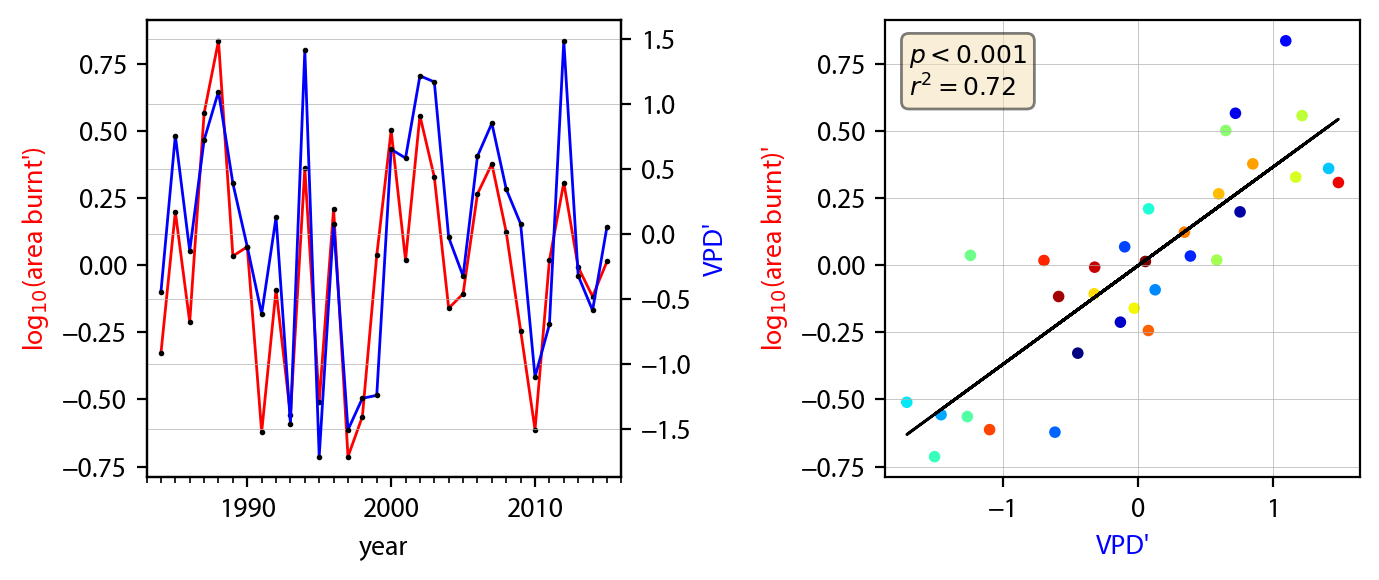

In [4]:

fig=plt.figure(figsize=(7,3),dpi=200)

# ----------------------------------
# plot detrended burnt area and VPD:
# ----------------------------------
plt.subplot(1,2,1)
ax1 = plt.gca()
ax1.plot(years,log_area_detrended,lw=1,color="r",label="log area burnt")
ax1.plot(years,log_area_detrended,'.',markersize=2,color="k")
ax1.set_xticks(range(1983,2017,1), minor=True)
ax2 = ax1.twinx()
ax2.plot(years,VPD_detrended,lw=1,color="b",label="VPD")
ax2.plot(years,VPD_detrended,'.',markersize=2,color="k")
ax1.set_xlim([1983,2016])
ax1.set_xlabel("year")
ax1.set_ylabel("log$_{10}$(area burnt')",color="r")
ax2.set_ylabel("VPD'",color="b")
ax.tick_params(axis='y', colors="r")
plt.grid(lw=0.25)

# ----------------------------------
# plot VPD to burnt area regression:
# ----------------------------------
plt.subplot(1,2,2)
plt.scatter(VPD_detrended,log_area_detrended,c=years,s=10,cmap='jet')
# plot the fitted regression line:
plt.plot(VPD_detrended,VPD_detrended*slope_detrended+intercept_detrended,color="k",lw=1)
plt.xlabel("VPD'",color="b")
plt.ylabel("log$_{10}$(area burnt)'",color="r")
plt.grid(lw=0.25)
# place a text box in upper left in axes coords
ax=plt.gca()
print("p=",p,"specifying p<0.001.")
pmax_detrended=np.maximum(p_detrended,0.001)
textstr = '\n'.join((
    r'$p<%.3f$' % (pmax_detrended, ),
    r'$r^2=%.2f$' % (r2_detrended, )))
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', bbox=props)


# finalize plot:
plt.tight_layout()
plt.show()